[INFO] No filter provided. Randomly selected protein: G1R9F8


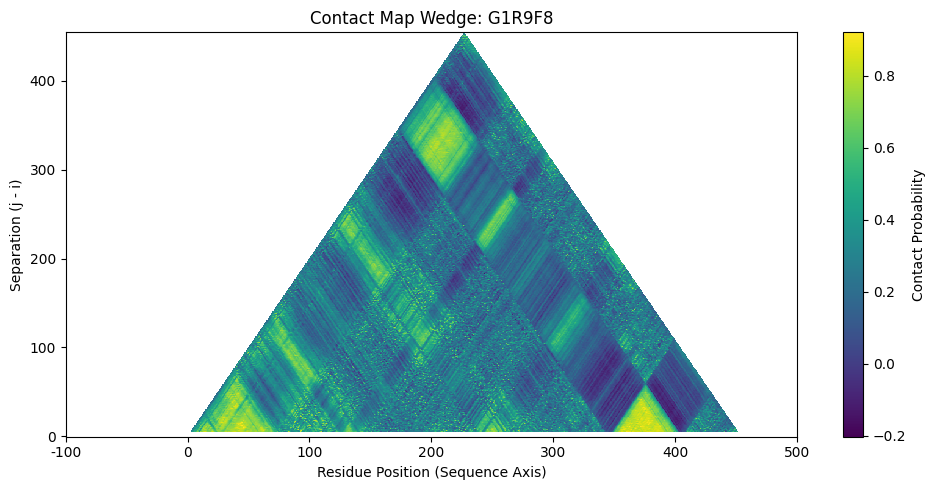

[PYTHON-INFO] date=2026-09-29 16:04:14 execution_time_sec=1.31 max_memory_mb=295.30


In [3]:
#!/usr/bin/env python3
"""Static symmetric contact map wedge visualizer with filled parity gaps and random/filtered selection."""
###################################### imports-and-config
import datetime, random, resource, time
import fastparquet, matplotlib.pyplot as plt, numpy as np, pandas as pd
from pyprojroot import here

FILE_PATH = here() / "data/contacts_esmc-6b_short/Mammalia_esmc6b_contacts.parquet"
START_TIME = time.time()
###################################### data-loading & filtering
df = pd.read_parquet(FILE_PATH, engine="fastparquet")
labels = df["accession"].unique().tolist()

# --- HARDCODED FILTER CONFIGURATION ---
# Set to a string (e.g. "ENS" or a specific accession) to filter, 
# or set to None / "" to pick a random protein by default.
FILTER_CRITERION = None 

if FILTER_CRITERION:
    matching_labels = [acc for acc in labels if str(FILTER_CRITERION) in str(acc)]
    if matching_labels:
        target_acc = random.choice(matching_labels)
        print(f"[INFO] Filter '{FILTER_CRITERION}' matched {len(matching_labels)} protein(s). Randomly selected: {target_acc}")
    else:
        print(f"[WARNING] Filter '{FILTER_CRITERION}' found no matches. Falling back to a completely random protein.")
        target_acc = random.choice(labels)
else:
    target_acc = random.choice(labels)
    print(f"[INFO] No filter provided. Randomly selected protein: {target_acc}")

###################################### plotting-logic
sub_df = df[df["accession"] == target_acc]

x_coords = sub_df["res_i"].values + sub_df["res_j"].values - 2
y_coords = sub_df["res_j"].values - sub_df["res_i"].values
vals = sub_df["value"].values

max_x, max_y = int(x_coords.max()) + 1, int(y_coords.max()) + 1
entry = np.full((max_y, max_x), np.nan)
for x, y, val in zip(x_coords, y_coords, vals):
    entry[int(y), int(x)] = val

if not np.isnan(entry).all():
    # Riempimento dei gap a scacchiera (parity gaps) per eliminare i puntini bianchi
    yy, xx = np.indices(entry.shape)
    mask_cb = ((xx + yy) % 2 == 1) & np.isnan(entry)
    for y, x in zip(*np.where(mask_cb)):
        if x > 0 and x < entry.shape[1] - 1 and not np.isnan(entry[y, x-1]) and not np.isnan(entry[y, x+1]):
            entry[y, x] = 0.5 * (entry[y, x-1] + entry[y, x+1])
        elif y > 0 and y < entry.shape[0] - 1 and not np.isnan(entry[y-1, x]) and not np.isnan(entry[y+1, x]):
            entry[y, x] = 0.5 * (entry[y-1, x] + entry[y+1, x])

    vmin, vmax = np.nanmin(entry), np.nanmax(entry)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    cax = ax.imshow(entry, cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest", aspect="auto", origin="lower")
    fig.colorbar(cax, label="Contact Probability")
    
    current_xticks = ax.get_xticks()
    ax.set_xticks(current_xticks)
    ax.set_xticklabels([int(val / 2) for val in current_xticks])
    
    ax.set_title(f"Contact Map Wedge: {target_acc}")
    ax.set_xlabel("Residue Position (Sequence Axis)")
    ax.set_ylabel("Separation (j - i)")
    plt.tight_layout()
    plt.show()

###################################### execution-logging
exec_time = time.time() - START_TIME
max_mem_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024
print(f"[PYTHON-INFO] date={datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')} execution_time_sec={exec_time:.2f} max_memory_mb={max_mem_mb:.2f}")